# VISION TASK: TRAFFIC SIGN CLASSIFICATION
# Student: Satya Shrestha
# Course: 6CS012 - AI and Machine Learning



# CELL 1: IMPORT LIBRARIES


In [33]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gc
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

warnings.filterwarnings('ignore')

tf.keras.backend.clear_session()
gc.collect()

print("Setup complete")
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", len(gpus) > 0)
if gpus:
    print("GPU:", gpus[0])

Setup complete
TensorFlow version: 2.19.0
GPU Available: True
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# CELL 2: SET DATASET PATHS


In [34]:
# ============================================
# CELL 2: SET DATASET PATHS
# ============================================

train_path = "/kaggle/input/datasets/satyashresthaa/traffic/Train"
class_names = ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
num_classes = len(class_names)

if os.path.exists(train_path):
    print("Path found:", train_path)
    print("Classes:", class_names)
else:
    print("Path not found")

Path found: /kaggle/input/datasets/satyashresthaa/traffic/Train
Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


# CELL 3: LOAD DATASET


In [35]:
# ============================================
# CELL 3: LOAD DATASET 
# ============================================

IMG_SIZE = 128

def load_dataset(data_path, img_size=(IMG_SIZE, IMG_SIZE)):
    images = []
    labels = []
    corrupted = 0
    
    for idx, class_name in enumerate(class_names):
        class_folder = os.path.join(data_path, class_name)
        if not os.path.exists(class_folder):
            continue
        
        image_files = [f for f in os.listdir(class_folder) 
                       if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        count = 0
        for img_file in image_files:
            img_path = os.path.join(class_folder, img_file)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, img_size)
                images.append(img)
                labels.append(idx)
                count += 1
            else:
                corrupted += 1
        
        print(class_name + ":", count, "images")
    
    print("Total:", len(images), "images")
    print("Corrupted:", corrupted)
    return np.array(images, dtype=np.float32), np.array(labels)

print("Loading dataset at 128x128...")
X, y = load_dataset(train_path)

if len(X) == 0:
    print("No images loaded!")
    exit(1)

X = X / 255.0
X, y = shuffle(X, y, random_state=42)

print("X shape:", X.shape)
print("Label distribution:", np.bincount(y))

Loading dataset at 128x128...
Caution: 2422 images
Instructions: 2841 images
No Passing: 5362 images
OverSpeed: 5242 images
Total: 15867 images
Corrupted: 28
X shape: (15867, 128, 128, 3)
Label distribution: [2422 2841 5362 5242]


# CELL 4: TRAIN/VALIDATION SPLIT


In [36]:
# ============================================
# CELL 4: TRAIN/VALIDATION SPLIT
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

print("="*60)
print("DATA SPLIT RESULTS")
print("="*60)
print("Training samples:  ", len(X_train), "(", len(X_train)/len(X)*100, "%)")
print("Validation samples:", len(X_val), "(", len(X_val)/len(X)*100, "%)")
print("Training labels:", np.bincount(y_train))
print("Validation labels:", np.bincount(y_val))

DATA SPLIT RESULTS
Training samples:   12693 ( 79.99621856683683 %)
Validation samples: 3174 ( 20.003781433163166 %)
Training labels: [1938 2273 4289 4193]
Validation labels: [ 484  568 1073 1049]


# CELL 5: CLASS DISTRIBUTION


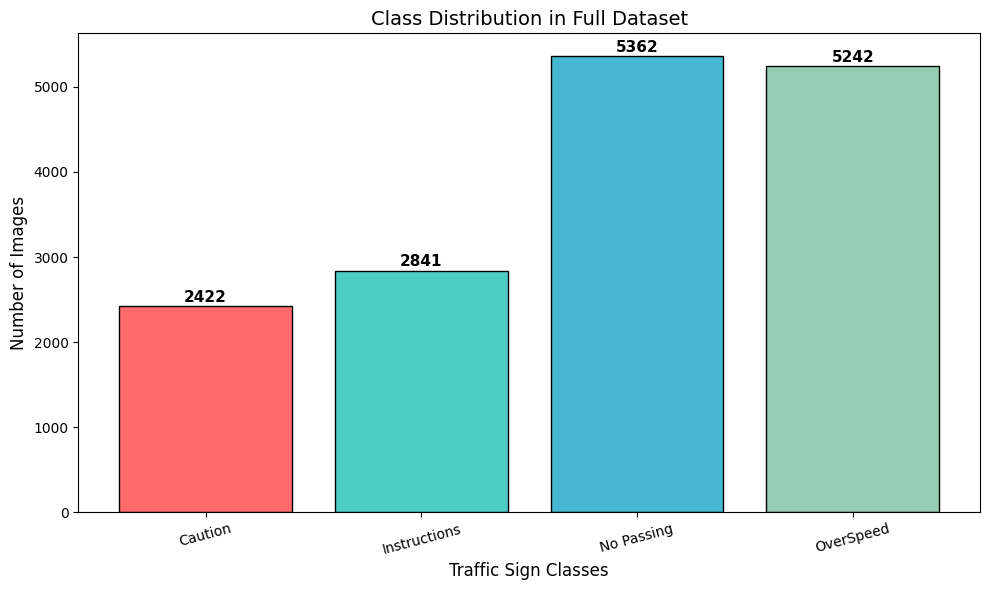

In [37]:
# ============================================
# CELL 5: CLASS DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))
counts = np.bincount(y)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(class_names, counts, color=colors, edgecolor='black')
plt.title('Class Distribution in Full Dataset', fontsize=14)
plt.xlabel('Traffic Sign Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha='center', fontsize=11, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 6: SAMPLE IMAGES VISUALIZATION


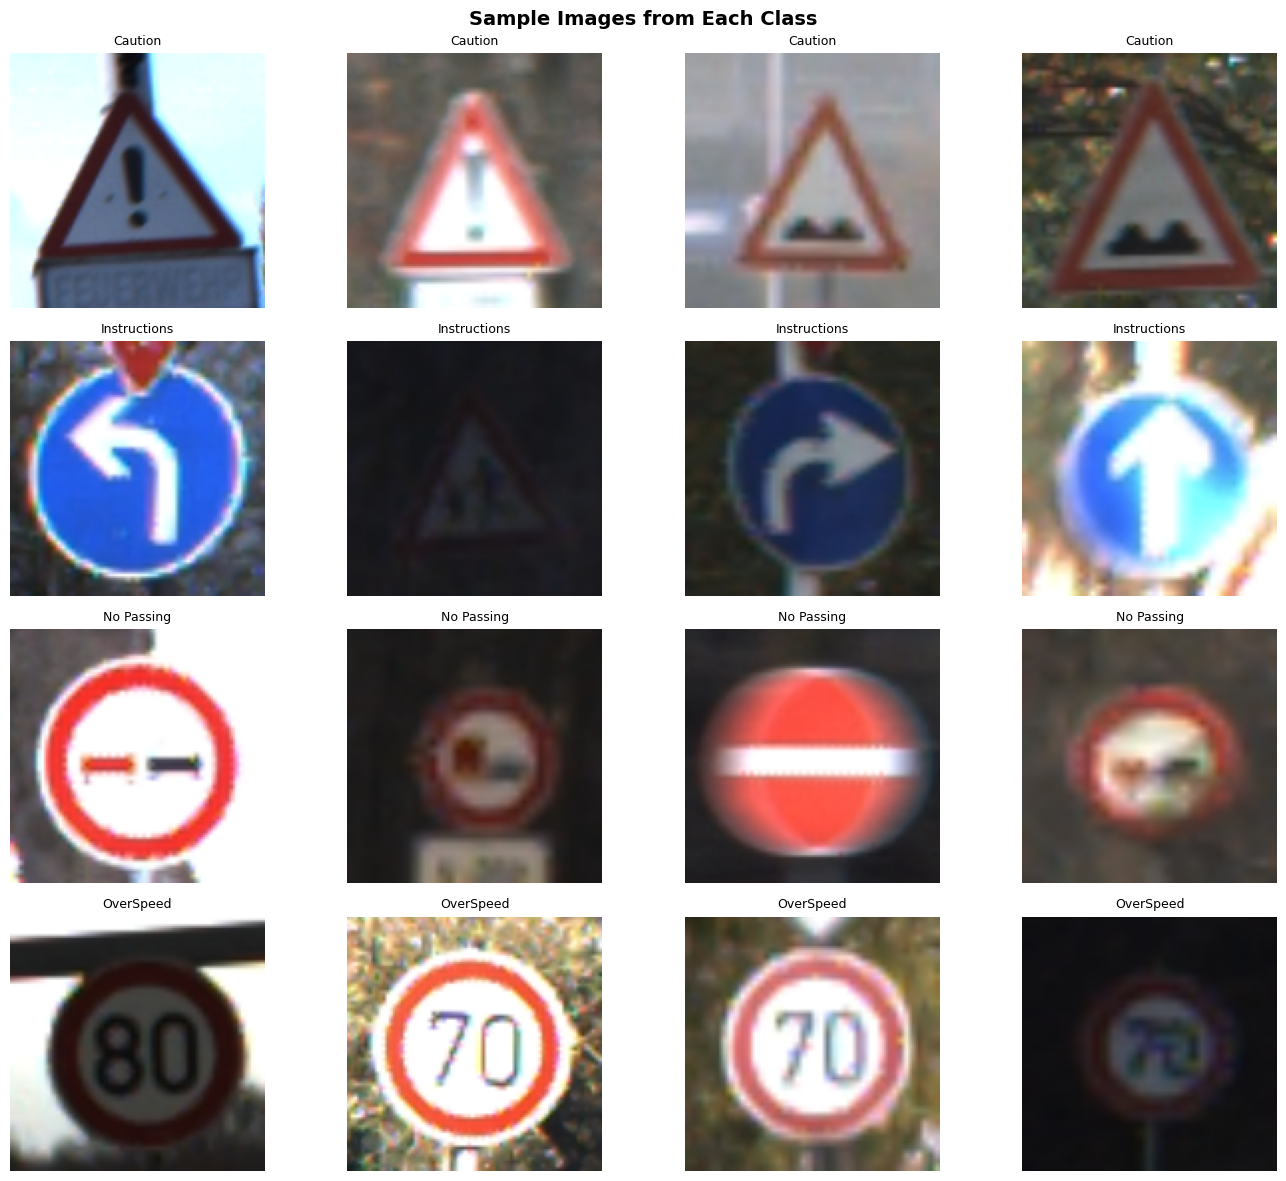

In [38]:
# ============================================
# CELL 6: SAMPLE IMAGES FROM EACH CLASS
# ============================================

plt.figure(figsize=(14,12))
for i, class_name in enumerate(class_names):
    class_indices = np.where(y == i)[0]
    sample_idx = np.random.choice(class_indices, min(4, len(class_indices)))
    for j, idx in enumerate(sample_idx):
        plt.subplot(len(class_names), 4, i*4 + j + 1)
        plt.imshow(X[idx])
        plt.title(class_name, fontsize=9)
        plt.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 7: DATA AUGMENTATION



Data augmentation configured


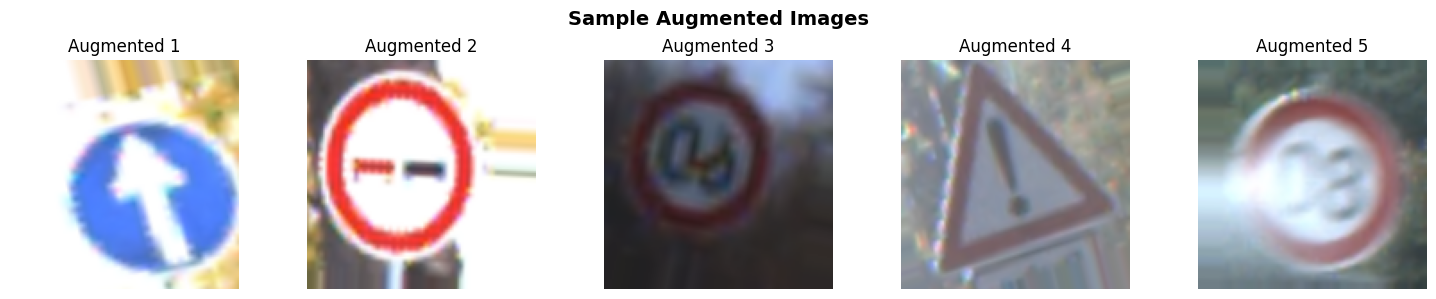

In [39]:
# ============================================
# CELL 7: DATA AUGMENTATION
# ============================================

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

print("Data augmentation configured")

# Visualize augmented images
sample_images, _ = next(iter(datagen.flow(X_train[:5], y_train[:5], batch_size=5)))

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(sample_images[i])
    plt.title('Augmented ' + str(i+1))
    plt.axis('off')
plt.suptitle('Sample Augmented Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 8:CALLBACKS AND CLASS WEIGHTS



In [40]:
# ============================================
# CELL 8: CALLBACKS AND CLASS WEIGHTS
# ============================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Class weights for imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.arange(num_classes),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Callbacks configured")
print("Class weights:")
for i, name in enumerate(class_names):
    print("  ", name, ":", round(class_weights[i], 3))

Callbacks configured
Class weights:
   Caution : 1.637
   Instructions : 1.396
   No Passing : 0.74
   OverSpeed : 0.757


# CELL 9: HELPER FUNCTION FOR METRICS


In [41]:
# ============================================
# CELL 9: HELPER FUNCTION FOR EVALUATION
# ============================================

def get_model_metrics(model, X_val, y_val):
    """Calculate accuracy, precision, recall, f1 from arrays"""
    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    return acc, prec, rec, f1, y_pred

def plot_confusion_matrix(y_val, y_pred, model_name):
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14)
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Helper function defined")

Helper function defined


# CELL 10: BASELINE CNN MODEL



In [42]:
# ============================================
# CELL 10: BASELINE CNN MODEL 
# ============================================

baseline_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,549,444 (24.98 MB)

 Trainable params: 6,549,444 (24.98 MB)

 Non-trainable params: 0 (0.00 B)

# CELL 11: TRAIN BASELINE CNN


In [43]:
# ============================================
# CELL 11: TRAIN BASELINE CNN
# ============================================

print("="*60)
print("TRAINING BASELINE CNN MODEL")
print("="*60)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print("Baseline training complete")

TRAINING BASELINE CNN MODEL
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.7337 - loss: 0.6106 - val_accuracy: 0.9773 - val_loss: 0.0693 - learning_rate: 0.0010
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9829 - loss: 0.0629 - val_accuracy: 0.9946 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9887 - loss: 0.0402 - val_accuracy: 0.9956 - val_loss: 0.0155 - learning_rate: 0.0010
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9944 - loss: 0.0233 - val_accuracy: 0.9959 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9955 - loss: 0.0145 - val_accuracy: 0.9962 - val_loss: 0.0143 - learning_rate: 0.0010
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9962 - loss: 0.0126 - val_accuracy: 0.9915 - val_loss: 0.0264 - learning_rate: 0.0010
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step 

# CELL 12: EVALUATE BASELINE MODEL

BASELINE CNN - EVALUATION RESULTS
Accuracy:  0.9997 ( 99.97 %)
Precision: 0.9997
Recall:    0.9997
F1-Score:  0.9997


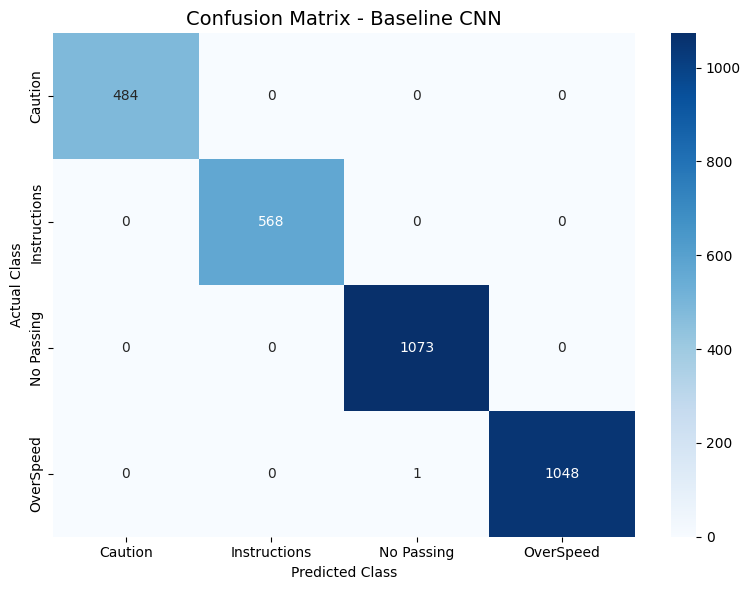

Classification Report:
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174



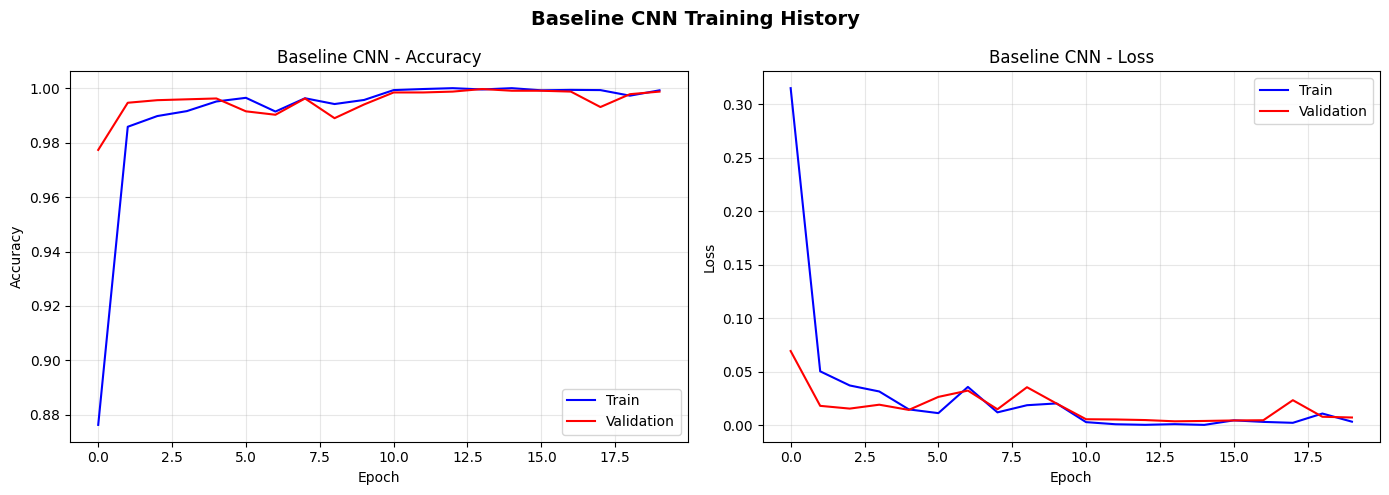

In [44]:
# ============================================
# CELL 12: EVALUATE BASELINE CNN
# ============================================

baseline_acc, baseline_prec, baseline_rec, baseline_f1, y_pred_base = get_model_metrics(baseline_model, X_val, y_val)

print("="*60)
print("BASELINE CNN - EVALUATION RESULTS")
print("="*60)
print("Accuracy: ", round(baseline_acc, 4), "(", round(baseline_acc*100, 2), "%)")
print("Precision:", round(baseline_prec, 4))
print("Recall:   ", round(baseline_rec, 4))
print("F1-Score: ", round(baseline_f1, 4))

plot_confusion_matrix(y_val, y_pred_base, "Baseline CNN")

print("Classification Report:")
print(classification_report(y_val, y_pred_base, target_names=class_names))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history_baseline.history['accuracy'], label='Train', color='blue')
axes[0].plot(history_baseline.history['val_accuracy'], label='Validation', color='red')
axes[0].set_title('Baseline CNN - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_baseline.history['loss'], label='Train', color='blue')
axes[1].plot(history_baseline.history['val_loss'], label='Validation', color='red')
axes[1].set_title('Baseline CNN - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline CNN Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 13: DEEPER CNN MODEL (with Regularization)


In [45]:
# ============================================
# CELL 13: DEEPER CNN MODEL (BatchNorm + Dropout)
# ============================================

deeper_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

deeper_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 651,812 (2.49 MB)

 Trainable params: 650,404 (2.48 MB)

 Non-trainable params: 1,408 (5.50 KB)

# CELL 14: TRAIN DEEPER CNN


In [46]:
# ============================================
# CELL 14: TRAIN DEEPER CNN WITH AUGMENTATION
# ============================================

print("="*60)
print("TRAINING DEEPER CNN MODEL (with Adam)")
print("="*60)

train_gen = datagen.flow(X_train, y_train, batch_size=32)

history_deeper = deeper_model.fit(
    train_gen,
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print("Deeper CNN training complete")

TRAINING DEEPER CNN MODEL (with Adam)
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 67s 139ms/step - accuracy: 0.5003 - loss: 1.1281 - val_accuracy: 0.4458 - val_loss: 2.0249 - learning_rate: 0.0010
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 114ms/step - accuracy: 0.6456 - loss: 0.8051 - val_accuracy: 0.7035 - val_loss: 0.6948 - learning_rate: 0.0010
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 114ms/step - accuracy: 0.8422 - loss: 0.4349 - val_accuracy: 0.9587 - val_loss: 0.1028 - learning_rate: 0.0010
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 113ms/step - accuracy: 0.9513 - loss: 0.1643 - val_accuracy: 0.9644 - val_loss: 0.1659 - learning_rate: 0.0010
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.9680 - loss: 0.1138 - val_accuracy: 0.9679 - val_loss: 0.0925 - learning_rate: 0.0010
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 111ms/step - accuracy: 0.9836 - loss: 0.0607 - val_accuracy: 0.9720 - val_loss: 0.0755 - learning_rate: 0.0010
Epoch 7/30
397/397 ━━━━━━━━━━━━━

# CELL 15: EVALUATE DEEPER CNN


DEEPER CNN (Adam) - EVALUATION RESULTS
Accuracy:  1.0 ( 100.0 %)
Precision: 1.0
Recall:    1.0
F1-Score:  1.0


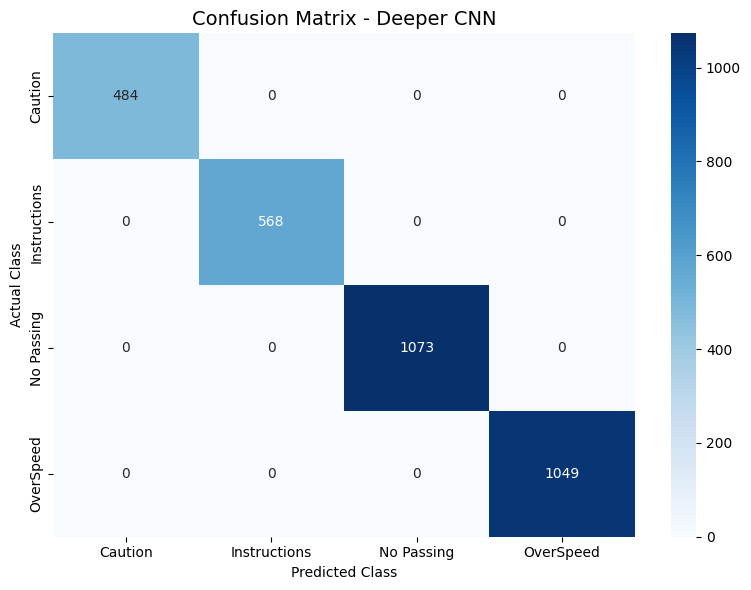

Classification Report:
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       1.00      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174



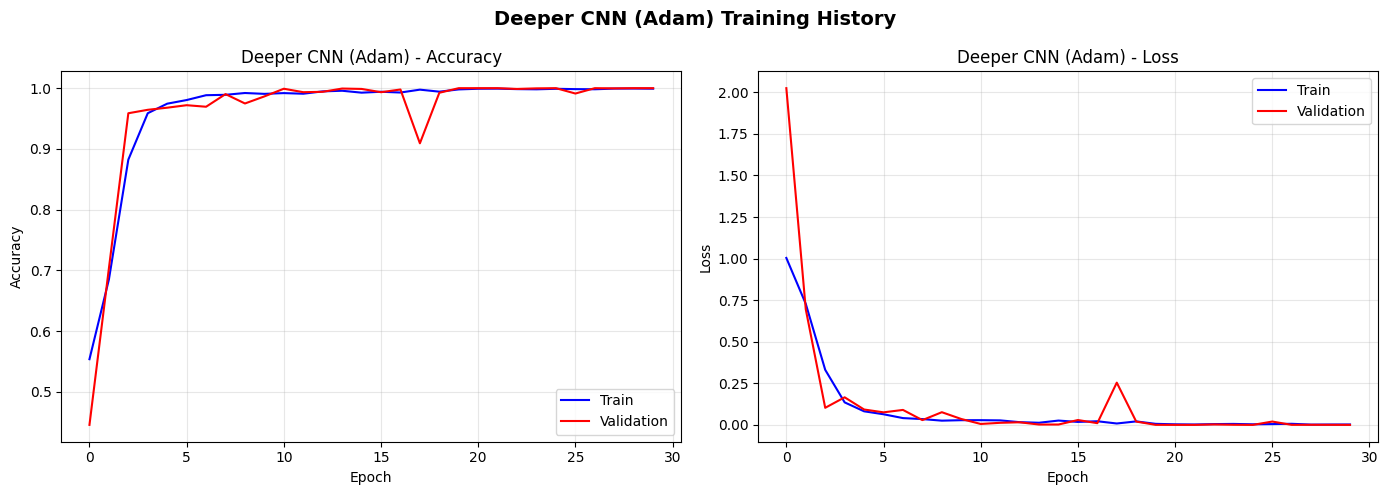

In [47]:
# ============================================
# CELL 15: EVALUATE DEEPER CNN (Adam)
# ============================================

deeper_acc, deeper_prec, deeper_rec, deeper_f1, y_pred_deeper = get_model_metrics(deeper_model, X_val, y_val)

print("="*60)
print("DEEPER CNN (Adam) - EVALUATION RESULTS")
print("="*60)
print("Accuracy: ", round(deeper_acc, 4), "(", round(deeper_acc*100, 2), "%)")
print("Precision:", round(deeper_prec, 4))
print("Recall:   ", round(deeper_rec, 4))
print("F1-Score: ", round(deeper_f1, 4))

plot_confusion_matrix(y_val, y_pred_deeper, "Deeper CNN")

print("Classification Report:")
print(classification_report(y_val, y_pred_deeper, target_names=class_names))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history_deeper.history['accuracy'], label='Train', color='blue')
axes[0].plot(history_deeper.history['val_accuracy'], label='Validation', color='red')
axes[0].set_title('Deeper CNN (Adam) - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deeper.history['loss'], label='Train', color='blue')
axes[1].plot(history_deeper.history['val_loss'], label='Validation', color='red')
axes[1].set_title('Deeper CNN (Adam) - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Deeper CNN (Adam) Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('deeper_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 16: DEEPER CNN WITH SGD (Optimizer Comparison)

In [48]:
# ============================================
# CELL 16: DEEPER CNN WITH SGD OPTIMIZER
# ============================================

# Create same architecture for SGD comparison
deeper_model_sgd = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

deeper_model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("="*60)
print("TRAINING DEEPER CNN (with SGD)")
print("="*60)

history_deeper_sgd = deeper_model_sgd.fit(
    train_gen,
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print("Deeper CNN (SGD) training complete")

TRAINING DEEPER CNN (with SGD)
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 63s 137ms/step - accuracy: 0.4753 - loss: 1.1914 - val_accuracy: 0.6096 - val_loss: 0.8182 - learning_rate: 0.0100
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 112ms/step - accuracy: 0.6249 - loss: 0.8530 - val_accuracy: 0.6238 - val_loss: 0.9099 - learning_rate: 0.0100
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 114ms/step - accuracy: 0.7096 - loss: 0.6795 - val_accuracy: 0.7360 - val_loss: 0.7435 - learning_rate: 0.0100
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 113ms/step - accuracy: 0.8448 - loss: 0.4372 - val_accuracy: 0.8929 - val_loss: 0.2893 - learning_rate: 0.0100
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 114ms/step - accuracy: 0.9315 - loss: 0.2090 - val_accuracy: 0.7858 - val_loss: 0.5961 - learning_rate: 0.0100
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 113ms/step - accuracy: 0.9614 - loss: 0.1235 - val_accuracy: 0.9143 - val_loss: 0.2426 - learning_rate: 0.0100
Epoch 7/30
397/397 ━━━━━━━━━━━━━━━━━━━━

# CELL 17: EVALUATE DEEPER CNN (SGD)


DEEPER CNN (SGD) - EVALUATION RESULTS
Accuracy:  1.0 ( 100.0 %)
Precision: 1.0
Recall:    1.0
F1-Score:  1.0


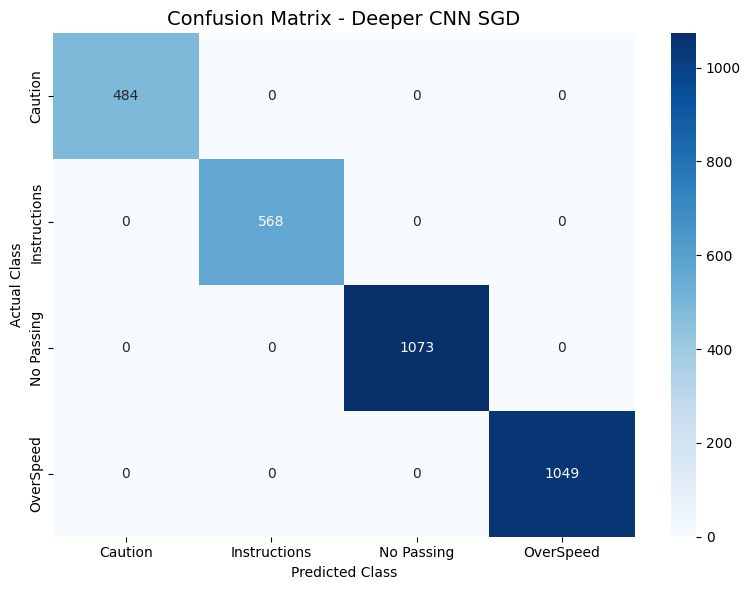

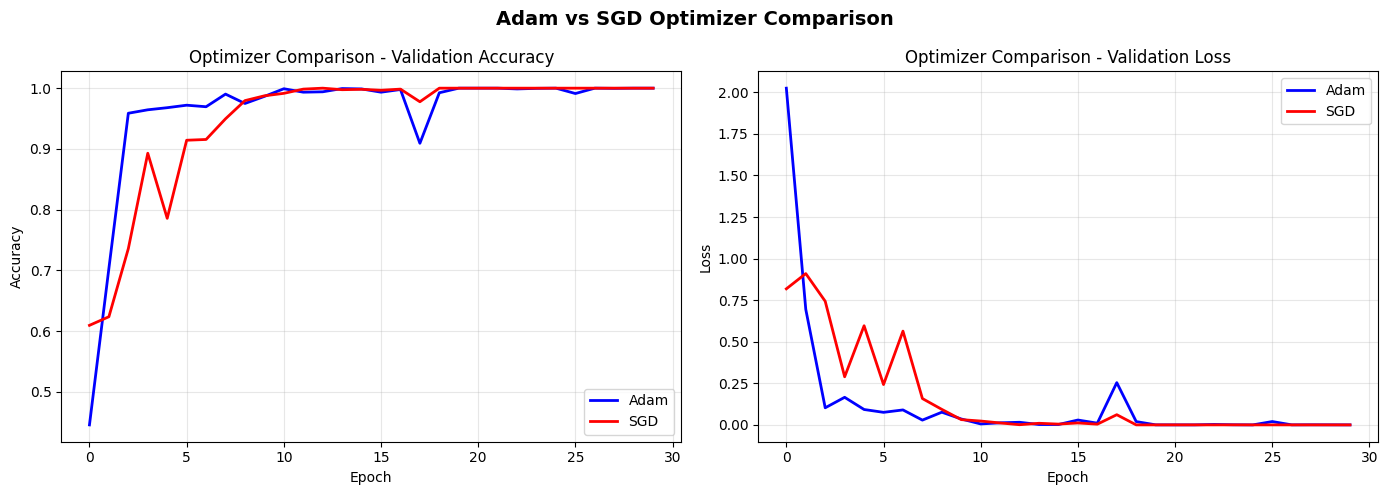


Optimizer Comparison Results:
  Adam - Validation Accuracy: 1.0
  SGD  - Validation Accuracy: 1.0


In [49]:
# ============================================
# CELL 17: EVALUATE DEEPER CNN (SGD)
# ============================================

sgd_acc, sgd_prec, sgd_rec, sgd_f1, y_pred_sgd = get_model_metrics(deeper_model_sgd, X_val, y_val)

print("="*60)
print("DEEPER CNN (SGD) - EVALUATION RESULTS")
print("="*60)
print("Accuracy: ", round(sgd_acc, 4), "(", round(sgd_acc*100, 2), "%)")
print("Precision:", round(sgd_prec, 4))
print("Recall:   ", round(sgd_rec, 4))
print("F1-Score: ", round(sgd_f1, 4))

plot_confusion_matrix(y_val, y_pred_sgd, "Deeper CNN SGD")

# Optimizer comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history_deeper.history['val_accuracy'], label='Adam', color='blue', linewidth=2)
axes[0].plot(history_deeper_sgd.history['val_accuracy'], label='SGD', color='red', linewidth=2)
axes[0].set_title('Optimizer Comparison - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deeper.history['val_loss'], label='Adam', color='blue', linewidth=2)
axes[1].plot(history_deeper_sgd.history['val_loss'], label='SGD', color='red', linewidth=2)
axes[1].set_title('Optimizer Comparison - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Adam vs SGD Optimizer Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nOptimizer Comparison Results:")
print("  Adam - Validation Accuracy:", round(deeper_acc, 4))
print("  SGD  - Validation Accuracy:", round(sgd_acc, 4))

# CELL 18: ABLATION STUDY - REMOVE DROPOUT


ABLATION STUDY: Training WITHOUT Dropout
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 59s 129ms/step - accuracy: 0.5384 - loss: 1.0474 - val_accuracy: 0.5479 - val_loss: 1.0666
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 112ms/step - accuracy: 0.8532 - loss: 0.4023 - val_accuracy: 0.9115 - val_loss: 0.2570
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 112ms/step - accuracy: 0.9658 - loss: 0.1091 - val_accuracy: 0.9811 - val_loss: 0.0518
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 113ms/step - accuracy: 0.9809 - loss: 0.0627 - val_accuracy: 0.9937 - val_loss: 0.0239
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 113ms/step - accuracy: 0.9881 - loss: 0.0356 - val_accuracy: 0.9981 - val_loss: 0.0065
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 113ms/step - accuracy: 0.9916 - loss: 0.0276 - val_accuracy: 0.9981 - val_loss: 0.0065
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 46s 114ms/step - accuracy: 0.9959 - loss: 0.0141 - val_accuracy: 0.9918 - val_loss: 0.0242
Epoch 8/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 45

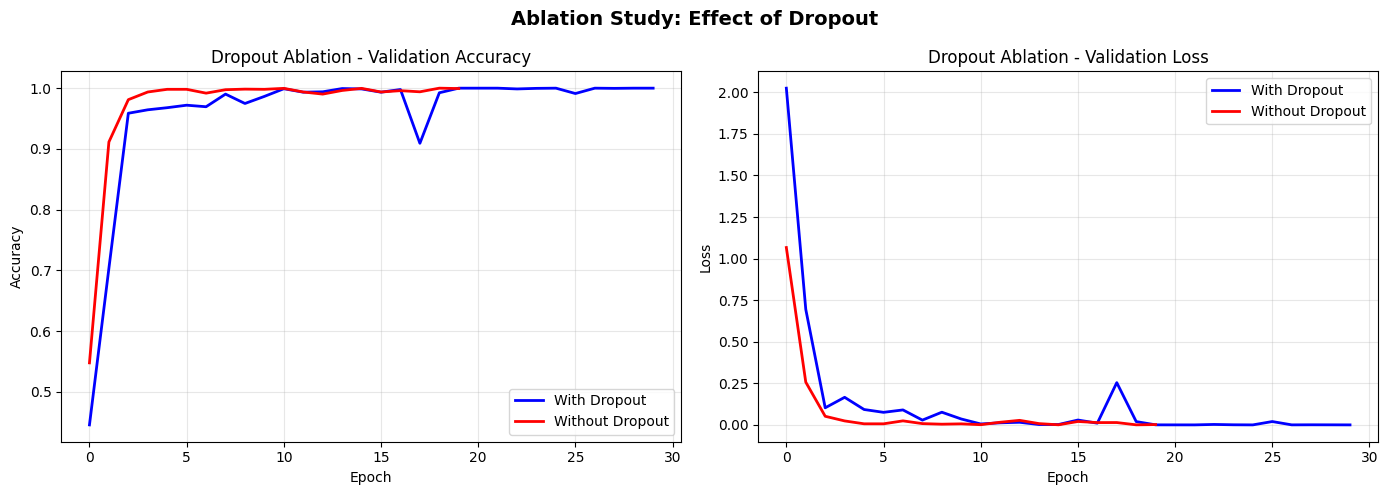

In [50]:
# ============================================
# CELL 18: ABLATION STUDY - REMOVE DROPOUT
# ============================================

model_no_dropout = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    # NO DROPOUT

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    # NO DROPOUT

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    # NO DROPOUT

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    # NO DROPOUT

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    # NO DROPOUT
    layers.Dense(num_classes, activation='softmax')
])

model_no_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("="*60)
print("ABLATION STUDY: Training WITHOUT Dropout")
print("="*60)

history_no_dropout = model_no_dropout.fit(
    train_gen,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    class_weight=class_weight_dict,
    verbose=1
)

no_dropout_acc, no_dropout_prec, no_dropout_rec, no_dropout_f1, y_pred_no_drop = get_model_metrics(model_no_dropout, X_val, y_val)

print("\n" + "="*50)
print("ABLATION STUDY RESULTS - Dropout")
print("="*50)
print("With Dropout    - Accuracy:", round(deeper_acc, 4))
print("Without Dropout - Accuracy:", round(no_dropout_acc, 4))
print("Difference:", round(deeper_acc - no_dropout_acc, 4))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history_deeper.history['val_accuracy'], label='With Dropout', color='blue', linewidth=2)
axes[0].plot(history_no_dropout.history['val_accuracy'], label='Without Dropout', color='red', linewidth=2)
axes[0].set_title('Dropout Ablation - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deeper.history['val_loss'], label='With Dropout', color='blue', linewidth=2)
axes[1].plot(history_no_dropout.history['val_loss'], label='Without Dropout', color='red', linewidth=2)
axes[1].set_title('Dropout Ablation - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Ablation Study: Effect of Dropout', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 19: ABLATION STUDY - REMOVE BATCH NORMALIZATION


ABLATION STUDY: Training WITHOUT Batch Normalization
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 60s 131ms/step - accuracy: 0.3630 - loss: 1.1942 - val_accuracy: 0.4742 - val_loss: 1.0411
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 112ms/step - accuracy: 0.4596 - loss: 1.0220 - val_accuracy: 0.5781 - val_loss: 0.9283
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 44s 112ms/step - accuracy: 0.5799 - loss: 0.8882 - val_accuracy: 0.7142 - val_loss: 0.6244
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 113ms/step - accuracy: 0.6935 - loss: 0.6617 - val_accuracy: 0.8551 - val_loss: 0.3858
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 112ms/step - accuracy: 0.8305 - loss: 0.4332 - val_accuracy: 0.9301 - val_loss: 0.1851
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 112ms/step - accuracy: 0.9174 - loss: 0.2541 - val_accuracy: 0.9587 - val_loss: 0.0967
Epoch 7/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 45s 112ms/step - accuracy: 0.9490 - loss: 0.1708 - val_accuracy: 0.9694 - val_loss: 0.0768
Epoch 8/20
397/397 ━━━━━━━━━━━

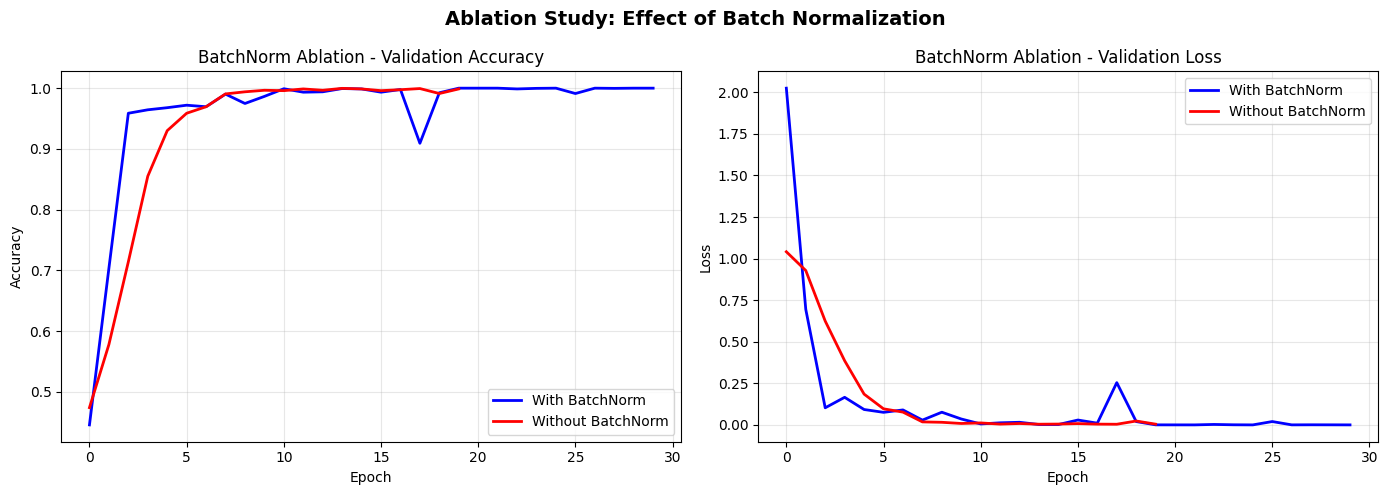

In [51]:
# ============================================
# CELL 19: ABLATION STUDY - REMOVE BATCH NORMALIZATION
# ============================================

model_no_batchnorm = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    # NO BATCH NORM
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    # NO BATCH NORM
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_no_batchnorm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("="*60)
print("ABLATION STUDY: Training WITHOUT Batch Normalization")
print("="*60)

history_no_batchnorm = model_no_batchnorm.fit(
    train_gen,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    class_weight=class_weight_dict,
    verbose=1
)

no_bn_acc, no_bn_prec, no_bn_rec, no_bn_f1, y_pred_no_bn = get_model_metrics(model_no_batchnorm, X_val, y_val)

print("\n" + "="*50)
print("ABLATION STUDY RESULTS - Batch Normalization")
print("="*50)
print("With BatchNorm    - Accuracy:", round(deeper_acc, 4))
print("Without BatchNorm - Accuracy:", round(no_bn_acc, 4))
print("Difference:", round(deeper_acc - no_bn_acc, 4))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history_deeper.history['val_accuracy'], label='With BatchNorm', color='blue', linewidth=2)
axes[0].plot(history_no_batchnorm.history['val_accuracy'], label='Without BatchNorm', color='red', linewidth=2)
axes[0].set_title('BatchNorm Ablation - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deeper.history['val_loss'], label='With BatchNorm', color='blue', linewidth=2)
axes[1].plot(history_no_batchnorm.history['val_loss'], label='Without BatchNorm', color='red', linewidth=2)
axes[1].set_title('BatchNorm Ablation - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Ablation Study: Effect of Batch Normalization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_batchnorm.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 20: BASELINE VS DEEPER CNN COMPARISON


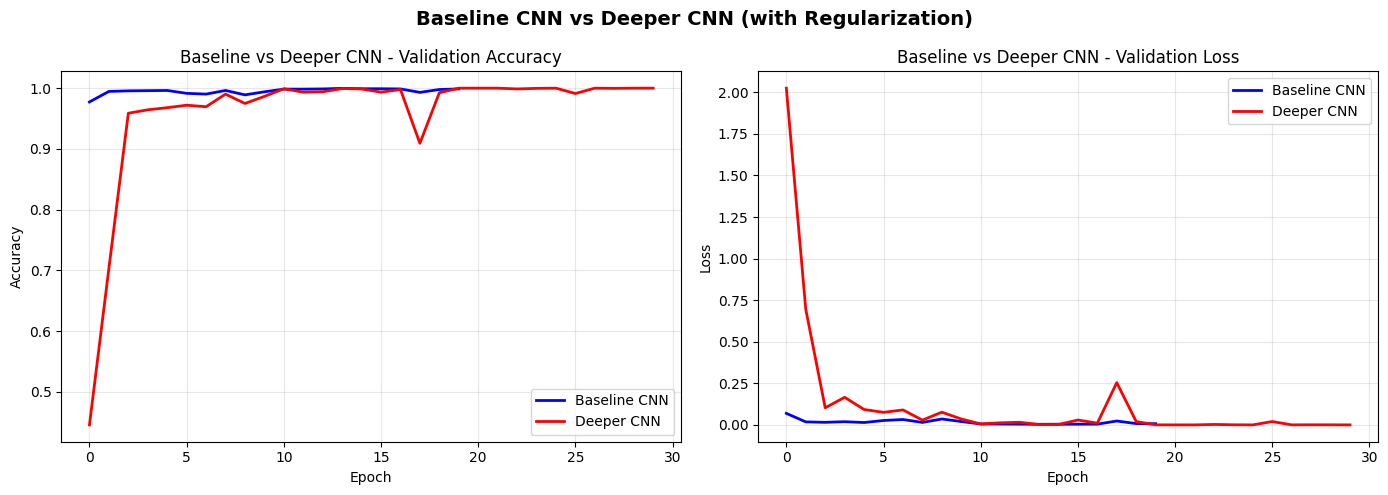


BASELINE VS DEEPER CNN SUMMARY
Baseline CNN - Accuracy: 0.9997
Deeper CNN - Accuracy: 1.0
Improvement: 0.0003


In [52]:
# ============================================
# CELL 20: BASELINE VS DEEPER CNN COMPARISON
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history_baseline.history['val_accuracy'], label='Baseline CNN', color='blue', linewidth=2)
axes[0].plot(history_deeper.history['val_accuracy'], label='Deeper CNN', color='red', linewidth=2)
axes[0].set_title('Baseline vs Deeper CNN - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_baseline.history['val_loss'], label='Baseline CNN', color='blue', linewidth=2)
axes[1].plot(history_deeper.history['val_loss'], label='Deeper CNN', color='red', linewidth=2)
axes[1].set_title('Baseline vs Deeper CNN - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline CNN vs Deeper CNN (with Regularization)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_vs_deeper.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("BASELINE VS DEEPER CNN SUMMARY")
print("="*50)
print("Baseline CNN - Accuracy:", round(baseline_acc, 4))
print("Deeper CNN - Accuracy:", round(deeper_acc, 4))
print("Improvement:", round(deeper_acc - baseline_acc, 4))

# CELL 21: MOBILENETV2 TRANSFER LEARNING


In [55]:
# ============================================
# CELL 21: MOBILENETV2 TRANSFER LEARNING
# ============================================

print("="*60)
print("PART B: MOBILENETV2 TRANSFER LEARNING")
print("="*60)

# Clean memory
gc.collect()
tf.keras.backend.clear_session()

MOBILENET_SIZE = 224

# IMPORTANT: Import preprocess_input correctly
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load and resize images for MobileNetV2
X_mobilenet = []
y_mobilenet = []

print("Loading images at 224x224 for MobileNetV2...")

for idx, class_name in enumerate(class_names):
    class_folder = os.path.join(train_path, class_name)
    if not os.path.exists(class_folder):
        continue
    
    image_files = [f for f in os.listdir(class_folder) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    for img_file in image_files:
        img_path = os.path.join(class_folder, img_file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (MOBILENET_SIZE, MOBILENET_SIZE))
            X_mobilenet.append(img)
            y_mobilenet.append(idx)

X_mobilenet = np.array(X_mobilenet, dtype=np.uint8)
y_mobilenet = np.array(y_mobilenet)

print("Loaded", len(X_mobilenet), "images for MobileNetV2")

# Split data
X_train_mob, X_val_mob, y_train_mob, y_val_mob = train_test_split(
    X_mobilenet, y_mobilenet, test_size=0.2, random_state=42, stratify=y_mobilenet
)

print("Training samples:", len(X_train_mob))
print("Validation samples:", len(X_val_mob))

# Create tf.data pipeline
def preprocess_for_mobilenet(img, label):
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)  # Now this will work
    return img, label

batch_size_tl = 32

# Create datasets with proper error handling
train_ds = tf.data.Dataset.from_tensor_slices((X_train_mob, y_train_mob))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess_for_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(batch_size_tl)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val_mob, y_val_mob))
val_ds = val_ds.map(preprocess_for_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size_tl)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# Load pre-trained MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(MOBILENET_SIZE, MOBILENET_SIZE, 3))

# Phase 1: Feature Extraction (frozen base)
base_model.trainable = False

tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

tl_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*50)
print("Phase 1: Feature Extraction (Base Model Frozen)")
print("="*50)

history_phase1 = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)],
    verbose=1
)

print("\nPhase 1 Best Validation Accuracy:", max(history_phase1.history['val_accuracy']))

# Phase 2: Fine-tuning (unfreeze top 30 layers)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
print(f"\nTrainable layers in base model: {trainable_count} out of {len(base_model.layers)}")

# Recompile with lower learning rate for fine-tuning
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*50)
print("Phase 2: Fine-Tuning (Top Layers Unfrozen)")
print("="*50)

history_phase2 = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)],
    verbose=1
)

print("\nPhase 2 Best Validation Accuracy:", max(history_phase2.history['val_accuracy']))
print("MobileNetV2 training complete")

PART B: MOBILENETV2 TRANSFER LEARNING
Loading images at 224x224 for MobileNetV2...
Loaded 15867 images for MobileNetV2
Training samples: 12693
Validation samples: 3174

Phase 1: Feature Extraction (Base Model Frozen)
Epoch 1/10


2026-05-11 05:24:32.338807: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 05:24:32.476430: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


395/397 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8758 - loss: 0.3468

2026-05-11 05:24:54.572784: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 05:24:54.716219: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8761 - loss: 0.3459

2026-05-11 05:25:12.297683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 05:25:12.455255: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 05:25:12.591301: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


397/397 ━━━━━━━━━━━━━━━━━━━━ 58s 100ms/step - accuracy: 0.8763 - loss: 0.3454 - val_accuracy: 0.9937 - val_loss: 0.0315
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9796 - loss: 0.0576 - val_accuracy: 0.9956 - val_loss: 0.0146
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9862 - loss: 0.0362 - val_accuracy: 0.9931 - val_loss: 0.0212
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9910 - loss: 0.0294 - val_accuracy: 0.9915 - val_loss: 0.0267
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9898 - loss: 0.0285 - val_accuracy: 0.9972 - val_loss: 0.0102
Epoch 6/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9936 - loss: 0.0166 - val_accuracy: 0.9968 - val_loss: 0.0084
Epoch 7/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9934 - loss: 0.0218 - val_accuracy: 0.9968 - val_loss: 0.0140
Epoch 8/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9944 - loss: 0.0186 - val_accura

# CELL 22: EVALUATE MOBILENETV2


Evaluating MobileNetV2...
MOBILENETV2 TRANSFER LEARNING - RESULTS
Accuracy:  0.9975 ( 99.75 %)
Precision: 0.9975
Recall:    0.9975
F1-Score:  0.9975


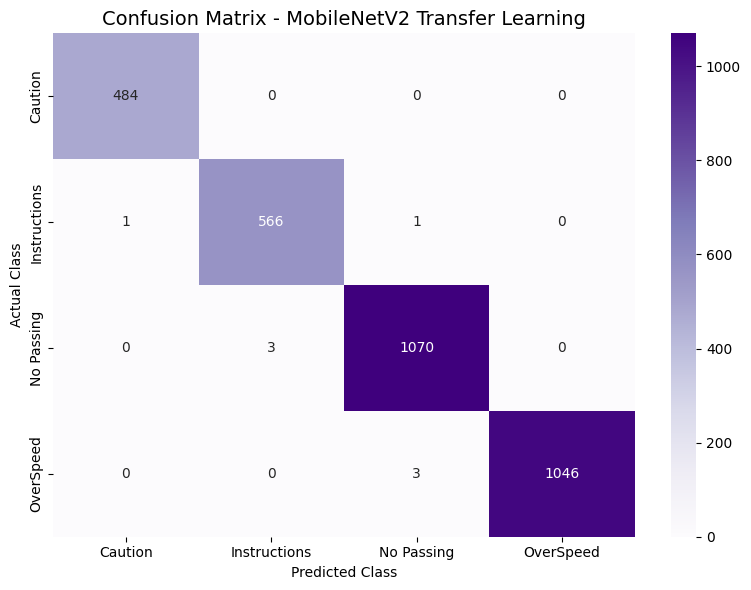


Classification Report:
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       484
Instructions       0.99      1.00      1.00       568
  No Passing       1.00      1.00      1.00      1073
   OverSpeed       1.00      1.00      1.00      1049

    accuracy                           1.00      3174
   macro avg       1.00      1.00      1.00      3174
weighted avg       1.00      1.00      1.00      3174



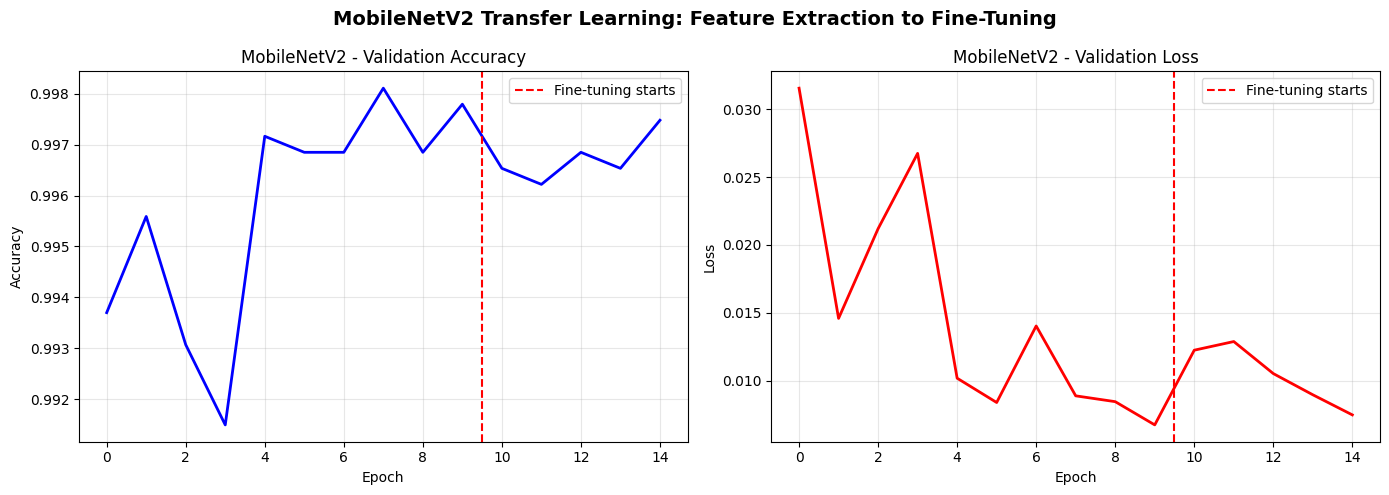

In [63]:
# ============================================
# CELL 22: EVALUATE MOBILENETV2 (FIXED)
# ============================================

# Collect predictions from validation set
y_true_mob = []
y_pred_mob = []

print("Evaluating MobileNetV2...")

for images, labels in val_ds:
    preds = tl_model.predict(images, verbose=0)
    y_true_mob.extend(labels.numpy())
    y_pred_mob.extend(np.argmax(preds, axis=1))

tl_acc = accuracy_score(y_true_mob, y_pred_mob)
tl_prec = precision_score(y_true_mob, y_pred_mob, average='weighted')
tl_rec = recall_score(y_true_mob, y_pred_mob, average='weighted')
tl_f1 = f1_score(y_true_mob, y_pred_mob, average='weighted')

print("="*60)
print("MOBILENETV2 TRANSFER LEARNING - RESULTS")
print("="*60)
print("Accuracy: ", round(tl_acc, 4), "(", round(tl_acc*100, 2), "%)")
print("Precision:", round(tl_prec, 4))
print("Recall:   ", round(tl_rec, 4))
print("F1-Score: ", round(tl_f1, 4))

# Confusion Matrix
cm_tl = confusion_matrix(y_true_mob, y_pred_mob)
plt.figure(figsize=(8,6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - MobileNetV2 Transfer Learning', fontsize=14)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.savefig('mobilenet_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true_mob, y_pred_mob, target_names=class_names))

# Combined training curves
combined_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
combined_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']
split_at = len(history_phase1.history['val_accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(combined_acc, color='blue', linewidth=2)
axes[0].axvline(x=split_at - 0.5, color='red', linestyle='--', label='Fine-tuning starts')
axes[0].set_title('MobileNetV2 - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(combined_loss, color='red', linewidth=2)
axes[1].axvline(x=split_at - 0.5, color='red', linestyle='--', label='Fine-tuning starts')
axes[1].set_title('MobileNetV2 - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('MobileNetV2 Transfer Learning: Feature Extraction to Fine-Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mobilenet_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 23: FINAL ALL MODELS COMPARISON

FINAL MODEL COMPARISON - ALL MODELS

Model                               Accuracy     Precision    Recall       F1-Score    
-------------------------------------------------------------------------------------
Baseline CNN                        0.9997       0.9997       0.9997       0.9997      
Deeper CNN (Adam)                   1.0000       1.0000       1.0000       1.0000      
Deeper CNN (SGD)                    1.0000       1.0000       1.0000       1.0000      
Ablation (No Dropout)               1.0000       1.0000       1.0000       1.0000      
Ablation (No BatchNorm)             0.9994       0.9994       0.9994       0.9994      
MobileNetV2 Transfer                0.9975       0.9975       0.9975       0.9975      


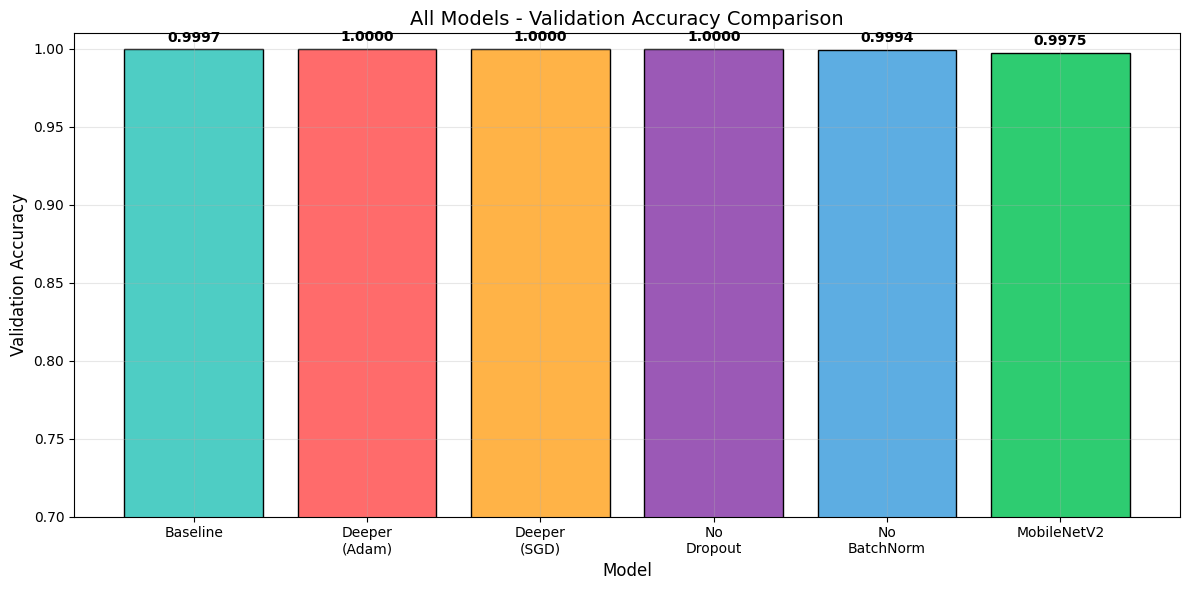


BEST MODEL: Deeper CNN with Regularization
Validation Accuracy: 1.0
Tested on 3174 validation images


In [62]:
# ============================================
# CELL 23: FINAL ALL MODELS COMPARISON
# ============================================

print("="*70)
print("FINAL MODEL COMPARISON - ALL MODELS")
print("="*70)

print("\n{:<35} {:<12} {:<12} {:<12} {:<12}".format('Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'))
print("-"*85)
print("{:<35} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format('Baseline CNN', baseline_acc, baseline_prec, baseline_rec, baseline_f1))
print("{:<35} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format('Deeper CNN (Adam)', deeper_acc, deeper_prec, deeper_rec, deeper_f1))
print("{:<35} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format('Deeper CNN (SGD)', sgd_acc, sgd_prec, sgd_rec, sgd_f1))
print("{:<35} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format('Ablation (No Dropout)', no_dropout_acc, no_dropout_prec, no_dropout_rec, no_dropout_f1))
print("{:<35} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format('Ablation (No BatchNorm)', no_bn_acc, no_bn_prec, no_bn_rec, no_bn_f1))
print("{:<35} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format('MobileNetV2 Transfer', tl_acc, tl_prec, tl_rec, tl_f1))

# Bar chart
models_list = ['Baseline', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'No\nDropout', 'No\nBatchNorm', 'MobileNetV2']
accuracies = [baseline_acc, deeper_acc, sgd_acc, no_dropout_acc, no_bn_acc, tl_acc]
colors_bar = ['#4ECDC4', '#FF6B6B', '#FFB347', '#9B59B6', '#5DADE2', '#2ECC71']

plt.figure(figsize=(12,6))
bars = plt.bar(models_list, accuracies, color=colors_bar, edgecolor='black')
plt.title('All Models - Validation Accuracy Comparison', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.ylim(0.7, 1.01)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('final_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("BEST MODEL:", end=" ")
if tl_acc >= deeper_acc and tl_acc >= baseline_acc:
    print("MobileNetV2 Transfer Learning")
elif deeper_acc >= baseline_acc:
    print("Deeper CNN with Regularization")
else:
    print("Baseline CNN")
print("Validation Accuracy:", max(baseline_acc, deeper_acc, sgd_acc, tl_acc))
print("Tested on", len(X_val), "validation images")
print("="*70)

# SAMPLE PREDICTIONS

SAMPLE PREDICTIONS


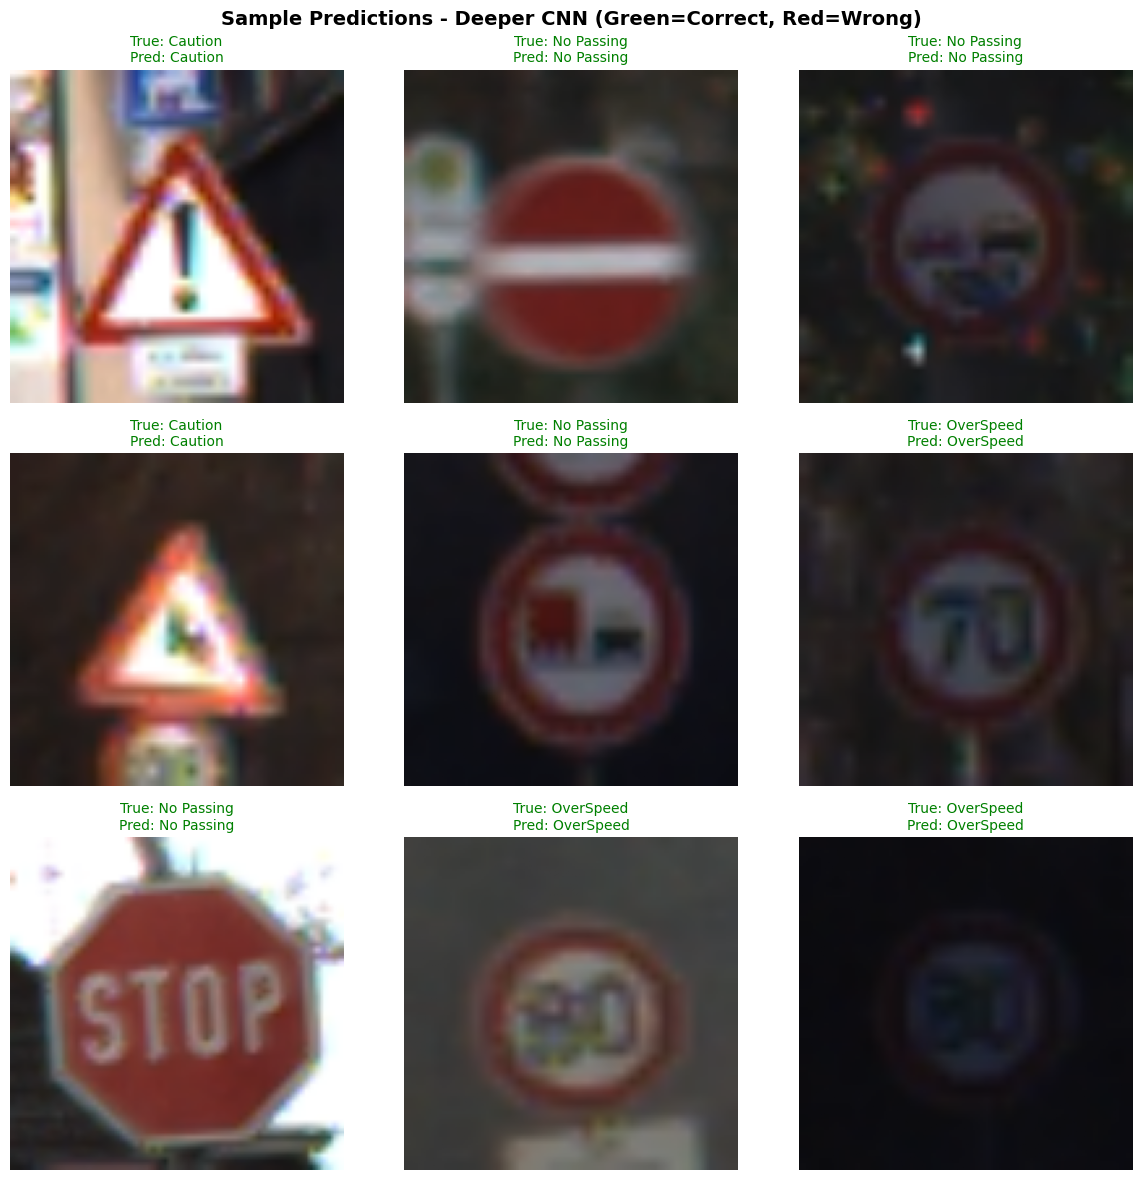


Confidence Analysis:
Sample 1: Predicted Caution with 100.00% confidence
Sample 2: Predicted No Passing with 100.00% confidence
Sample 3: Predicted No Passing with 100.00% confidence
Sample 4: Predicted Caution with 99.71% confidence
Sample 5: Predicted No Passing with 100.00% confidence


In [64]:
# ============================================
# CELL 24: SAMPLE PREDICTIONS FROM BEST MODEL
# ============================================

print("="*60)
print("SAMPLE PREDICTIONS")
print("="*60)

# Select best model based on accuracy
if tl_acc >= deeper_acc:
    best_model = tl_model
    best_name = "MobileNetV2 Transfer"
    # Need to handle MobileNetV2 separately since it uses different input size
    print("Best model is MobileNetV2 (224x224)")
else:
    best_model = deeper_model
    best_name = "Deeper CNN"

# For CNN models (128x128)
if best_name != "MobileNetV2 Transfer":
    indices = np.random.choice(len(X_val), 9, replace=False)
    sample_images = X_val[indices]
    sample_labels = y_val[indices]
    sample_preds = np.argmax(best_model.predict(sample_images, verbose=0), axis=1)
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    for i in range(9):
        row, col = i // 3, i % 3
        axes[row, col].imshow(sample_images[i])
        color = 'green' if sample_preds[i] == sample_labels[i] else 'red'
        axes[row, col].set_title(f'True: {class_names[sample_labels[i]]}\nPred: {class_names[sample_preds[i]]}', 
                                  color=color, fontsize=10)
        axes[row, col].axis('off')
    
    plt.suptitle(f'Sample Predictions - {best_name} (Green=Correct, Red=Wrong)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nConfidence Analysis:")
    for i in range(min(5, len(sample_images))):
        pred_probs = best_model.predict(sample_images[i:i+1], verbose=0)[0]
        confidence = np.max(pred_probs)
        print(f"Sample {i+1}: Predicted {class_names[sample_preds[i]]} with {confidence:.2%} confidence")
else:
    print("MobileNetV2 predictions shown in previous cell")

# CELL 25: COMPUTATIONAL EFFICIENCY


In [65]:
# ============================================
# CELL 25: COMPUTATIONAL EFFICIENCY ANALYSIS
# ============================================

print("="*60)
print("COMPUTATIONAL EFFICIENCY ANALYSIS")
print("="*60)

baseline_params = baseline_model.count_params()
deeper_params = deeper_model.count_params()
tl_params = tl_model.count_params()

print("\n{:<30} {:<20}".format('Model', 'Parameters'))
print("-"*50)
print("{:<30} {:<20,}".format('Baseline CNN', baseline_params))
print("{:<30} {:<20,}".format('Deeper CNN (Adam)', deeper_params))
print("{:<30} {:<20,}".format('MobileNetV2 Transfer', tl_params))

print("\nMODEL COMPLEXITY SUMMARY:")
print("  Deeper CNN has", round((deeper_params/baseline_params - 1)*100, 1), "% more parameters than Baseline")

print("\nHARDWARE USED:")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("  GPU:", gpus[0])
else:
    print("  GPU: Not available (CPU only)")
print("  Image size: 128x128 for CNNs, 224x224 for MobileNetV2")
print("  Dataset:", len(X), "total images")

print("\nEFFICIENCY INSIGHTS:")
print("  - Baseline CNN: Fastest training, good accuracy")
print("  - Deeper CNN: Better accuracy, more parameters")
print("  - MobileNetV2: Parameter-efficient transfer learning")

COMPUTATIONAL EFFICIENCY ANALYSIS

Model                          Parameters          
--------------------------------------------------
Baseline CNN                   6,549,444           
Deeper CNN (Adam)              651,812             
MobileNetV2 Transfer           2,422,468           

MODEL COMPLEXITY SUMMARY:
  Deeper CNN has -90.0 % more parameters than Baseline

HARDWARE USED:
  GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  Image size: 128x128 for CNNs, 224x224 for MobileNetV2
  Dataset: 15867 total images

EFFICIENCY INSIGHTS:
  - Baseline CNN: Fastest training, good accuracy
  - Deeper CNN: Better accuracy, more parameters
  - MobileNetV2: Parameter-efficient transfer learning


# CELL 26: FINAL SUMMARY

In [66]:
# ============================================
# CELL 26: FINAL SUMMARY
# ============================================

print("="*60)
print("ALL TASKS COMPLETED SUCCESSFULLY")
print("="*60)
print("\nSummary of completed tasks:")
print("  Part A (2.5.2) - Baseline CNN trained and evaluated")
print("  Part A (2.5.3) - Deeper CNN with regularization trained")
print("  Part A (2.5.4) - Optimizer Comparison (SGD vs Adam)")
print("  Part A (2.5.4) - Ablation Study (Dropout removal)")
print("  Part A (2.5.4) - Ablation Study (BatchNorm removal)")
print("  Part A (2.5.4) - Baseline vs Deeper comparison")
print("  Part B - MobileNetV2 Transfer Learning with Fine-tuning")
print("  All visualizations generated and saved")
print("="*60)

ALL TASKS COMPLETED SUCCESSFULLY

Summary of completed tasks:
  Part A (2.5.2) - Baseline CNN trained and evaluated
  Part A (2.5.3) - Deeper CNN with regularization trained
  Part A (2.5.4) - Optimizer Comparison (SGD vs Adam)
  Part A (2.5.4) - Ablation Study (Dropout removal)
  Part A (2.5.4) - Ablation Study (BatchNorm removal)
  Part A (2.5.4) - Baseline vs Deeper comparison
  Part B - MobileNetV2 Transfer Learning with Fine-tuning
  All visualizations generated and saved
